### Step 1: Do the necessary imports(shown in code) and execute pip installs for the libraries mentioned. Please refer to the document sent for step-by-step clear explanation

### Step 2: Gather PDF File Paths

After setting up the environment and defining our configuration, the first action the script takes is to find all the PDF files it needs to process.

This section of the code defines a function to do this and then calls that function to create a list of all the PDF letters we've placed in the specified input directory.

### Step 3: OCR / PDF Text Extraction

This section contains the functions responsible for reading the content of each PDF file. It's designed to handle both standard PDFs (where text can be copied and pasted) and scanned PDFs (which are essentially images of text).

Here's the code:
### Step 4: Quarter Helpers

Hedge fund letters are typically issued for a specific quarter (Q1, Q2, Q3, or Q4) of a particular year. To analyze performance accurately, the script needs to identify this quarter and year.

This section provides functions to:

1.  Map quarter names (like "first", "second") to standard labels ("Q1", "Q2").
2.  Determine the start and end dates for a given quarter and year.
3.  Attempt to find the quarter label and year by scanning the text of the letter for common phrases.

Here's the code for these helpers:
### Step 5: Letter Metadata Helpers

This section contains functions designed to pull out specific pieces of information from the letter's text, such as:

*   The date the letter was issued.
*   The name of the hedge fund or firm.
*   The name of the portfolio manager or author.
*   The fund's reported return for the quarter.
*   Any benchmark returns mentioned in the letter.

The code uses regular expressions and heuristics (rules of thumb based on how these letters are typically formatted) to find this information.

Here's the code for these helpers:
### Step 6: Hedge / Disclaimer Split

Hedge fund letters often contain a significant section at the end dedicated to legal disclaimers, risk warnings, and other boilerplate language. For analysis focusing on the fund's strategy and performance discussion, it's helpful to separate this "hedge" section from the main body of the letter.

This section of the code does exactly that by looking for predefined markers that typically signal the start of these disclaimers.

Here's the code:

### Step 7: Index Returns + Alpha

To understand how well a hedge fund performed, we often compare its return to a relevant market benchmark (like the S&P 500). "Alpha" is the difference between the fund's return and the benchmark's return.

This section of the code does two main things:

1.  It uses the `yfinance` library to download the actual historical prices for the benchmark indices we specified in the `BENCHMARK_TICKERS` list for the exact quarter mentioned in the letter. It then calculates the percentage return for that benchmark over that period.
2.  It calculates the "alpha" by subtracting the benchmark's return from the fund's reported return for the quarter.

Here's the code:

### Step 8: Main Processing Loop

This section contains the core logic that processes each PDF file. It iterates through the list of PDF files and, for each file, applies the helper functions we defined earlier to extract and calculate all the relevant information.

The extracted data for each letter and each benchmark is then stored as a row in a list, which will be used to create a structured table (a pandas DataFrame) in the next step.

Here's the code for the main loop:

### Step 9: Build DataFrame + Export

The final step is to take the list of rows collected during the main processing loop and turn it into a structured table using the `pandas` library. This table, called a DataFrame, is much easier to analyze and work with.

Once the DataFrame is created, the script saves it to a CSV (Comma Separated Values) file. CSV files are a common format that can be opened in spreadsheet programs like Google Sheets, Excel, or loaded into other data analysis tools.

Here's the code for the final step:

In [48]:
# ============================
# 0. INSTALL DEPENDENCIES
# ============================
!pip install pdfplumber pytesseract pillow pdf2image yfinance pandas regex python-dateutil --quiet

# If pytesseract is missing binary in Colab, uncomment these:
# !apt-get update
# !apt-get install -y tesseract-ocr poppler-utils

# ============================
# 1. IMPORTS & CONFIG
# ============================
import os
import re
import datetime
import pdfplumber
import pytesseract
import pandas as pd
import yfinance as yf
from dateutil import parser as dateparser
from pdf2image import convert_from_path

# --------- USER CONFIG ---------
# Put ALL your PDF letters into this folder in Colab.
INPUT_DIR = "/content/HedgeFundLetters"

# Benchmarks we care about and want alpha vs.
# You can extend this dict later, e.g. "NASDAQ": "^IXIC"
BENCHMARK_TICKERS = {
    "S&P 500": "^GSPC",
    "Russell 2000": "^RUT",
}

# Aggressive hedge/disclaimer markers.
# We split the letter at the FIRST occurrence of any of these (case-insensitive).
HEDGE_SECTION_START_MARKERS = [
    "disclosure",
    "disclosures",
    "disclaimer",
    "disclaimers",
    "important disclosures",
    "confidential",
    "confidentiality notice",
    "past performance is not",
    "past performance may not",
    "forward-looking statements",
    "forward looking statements",
    "this letter is for informational purposes only",
    "this letter is provided solely for",
    "this communication does not",
    "this material does not constitute",
    "this material is not an offer",
    "this is not an offer",
    "shall not constitute an offer",
    "does not constitute an offer",
    "the information contained herein",
    "the information contained in this letter",
    "investing involves risk",
    "risk of loss",
    "no assurance can be given",
    "not necessarily indicative of future results",
    "not indicative of future results",
    "certain statements contained herein",
    "may contain forward-looking",
]

# ============================
# 2. UTILS: LOAD ALL PDF FILES
# ============================
def get_all_pdfs(folder: str):
    pdfs = []
    for fname in os.listdir(folder):
        if fname.lower().endswith(".pdf"):
            pdfs.append(os.path.join(folder, fname))
    pdfs.sort()
    return pdfs

PDF_FILES = get_all_pdfs(INPUT_DIR)

# ============================
# 3. OCR / PDF TEXT EXTRACTION
# ============================
def ocr_pdf_page(pil_image):
    """OCR a PIL image page using Tesseract."""
    return pytesseract.image_to_string(pil_image)

def extract_text_from_pdf(pdf_path: str) -> str:
    """
    For each page:
      1. Try pdfplumber text extraction.
      2. If very little text, OCR that page instead.
    Join all pages.
    """
    chunks = []
    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages):
            txt = page.extract_text() or ""
            # Heuristic: if <50 non-space chars, treat as scanned, do OCR
            if len(re.sub(r"\s+", "", txt)) < 50:
                imgs = convert_from_path(pdf_path, first_page=i+1, last_page=i+1)
                if imgs:
                    ocr_txt = ocr_pdf_page(imgs[0])
                    chunks.append(ocr_txt)
                else:
                    chunks.append(txt)
            else:
                chunks.append(txt)
    return "\n".join(chunks)

# ============================
# 4. QUARTER HELPERS
# ============================
QUARTER_WORD_TO_LABEL = {
    "first": "Q1",
    "second": "Q2",
    "third": "Q3",
    "fourth": "Q4",
}

def get_quarter_date_range(quarter_label: str, year: int):
    """
    quarter_label: "Q1","Q2","Q3","Q4"
    year: int like 2025
    returns (start_date_str, end_date_str)
    """
    if quarter_label not in ["Q1","Q2","Q3","Q4"] or year is None:
        return None, None

    start_month = {"Q1": 1, "Q2": 4, "Q3": 7, "Q4": 10}[quarter_label]
    end_month   = {"Q1": 3, "Q2": 6, "Q3": 9, "Q4": 12}[quarter_label]

    start_date = datetime.date(year, start_month, 1)

    if end_month == 12:
        next_month_first = datetime.date(year+1, 1, 1)
    else:
        next_month_first = datetime.date(year, end_month+1, 1)
    end_date = next_month_first - datetime.timedelta(days=1)

    return start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d")

def guess_quarter_and_year(text: str):
    """
    Extract quarter_label (Q1..Q4) and quarter_year (YYYY).
    Supports:
      - "in the third quarter of 2025"
      - "2025 Third Quarter"
      - "Q3 2025"
      - "During the Second Quarter, ..."
    """
    # pattern A: "in the third quarter of 2025"
    m = re.search(r"(first|second|third|fourth)\s+quarter\s+of\s+(20\d{2})",
                  text, flags=re.IGNORECASE)
    if m:
        qlabel = QUARTER_WORD_TO_LABEL[m.group(1).lower()]
        return qlabel, int(m.group(2))

    # pattern B: "2025 Third Quarter"
    m = re.search(r"(20\d{2})\s+(first|second|third|fourth)\s+quarter",
                  text, flags=re.IGNORECASE)
    if m:
        qlabel = QUARTER_WORD_TO_LABEL[m.group(2).lower()]
        return qlabel, int(m.group(1))

    # pattern C: "Q3 2025"
    m = re.search(r"(Q[1-4])\s+(20\d{2})", text, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper(), int(m.group(2))

    # pattern D: "During the Second Quarter, ..."
    m = re.search(r"(During|In)\s+the\s+(first|second|third|fourth)\s+quarter[, ]",
                  text, flags=re.IGNORECASE)
    if m:
        qlabel = QUARTER_WORD_TO_LABEL[m.group(2).lower()]

        snippet = text[m.end(): m.end()+200]
        y = re.search(r"(20\d{2})", snippet)
        if y:
            return qlabel, int(y.group(1))
        else:
            return qlabel, None

    return "", None

# ============================
# 5. LETTER METADATA HELPERS
# ============================
MONTH_PATTERN = r"(January|February|March|April|May|June|July|August|September|October|November|December)"
DATE_REGEX = re.compile(rf"{MONTH_PATTERN}\s+\d{{1,2}},\s+\d{{4}}")

def guess_letter_date(text: str) -> str:
    """
    Get the first 'Month DD, YYYY' and return ISO date.
    """
    m = DATE_REGEX.search(text)
    if not m:
        return ""
    dt = dateparser.parse(m.group(0))
    return dt.strftime("%Y-%m-%d")

def extract_fund_name_from_perf_intro(text: str) -> str:
    """
    Try to grab the fund / firm name the way Third Point does it:
    "During the Fourth Quarter, Third Point returned 9.1% ..."
    We capture "Third Point" etc.
    """
    pat = re.compile(
        r"(?:During|In)\s+the\s+(first|second|third|fourth)\s+quarter[^,]*,\s+"
        r"([A-Z][A-Za-z0-9&.\- ]{2,80}?)\s+"
        r"(?:returned|generated|produced a return of|was up|increased(?:\s+by)?|rose|gained|advanced|grew|declined|fell|decreased)",
        flags=re.IGNORECASE | re.DOTALL,
    )
    m = pat.search(text)
    if m:
        cand = m.group(2).strip()
        # light cleanup: chop trailing junk like possessives etc
        cand = re.sub(r"’s$|'s$", "", cand).strip()
        return cand
    return ""

def normalize_firm_name(name: str) -> str:
    """
    Clean extra leading phrases like:
      'To the Investors in Third Point Investors Limited'
    -> 'Third Point Investors Limited'

    Also handles:
      'To our partners in Cedar Creek Partners LLC'
    -> 'Cedar Creek Partners LLC'
    """
    if not name:
        return name

    # strip leading address phrases
    name2 = re.sub(
        r"^(to\s+(the|our)\s+(investors?|partners?)\s+(in|of)\s+)",
        "",
        name,
        flags=re.IGNORECASE,
    )

    # collapse repeated whitespace and trailing commas
    name2 = re.sub(r"\s+", " ", name2).strip(" ,")
    return name2.strip()


def clean_firm_candidate(cand: str) -> str:
    """
    Given a nearby line (signature block, header, etc.), try to turn it into a
    clean firm/fund name.

    Examples we want:
      'Alluvial Capital Management, LLC'
      'Cedar Creek Partners LLC'
      'Eriksen Capital Management LLC'
      'Third Point Investors Limited'  <-- from 'To the Investors in Third Point Investors Limited'
    """

    # strip titles/credentials after the name
    cand = re.sub(r",?\s*CFA\b.*", "", cand, flags=re.IGNORECASE)
    cand = re.sub(r"\b(CEO|CIO|Managing Partner|Managing Member|Portfolio Manager|Founder)\b.*", "", cand, flags=re.IGNORECASE)
    cand = cand.strip()

    # Special-case "Third Point ..." first so we don't keep the leading 'To the investors in ...'
    tp_pat = re.compile(
        r"\b(Third Point(?:\s+(?:Partners(?:\s+L\.?P\.?)?|"
        r"Offshore\s+Fund(?:,?\s+Ltd\.?)?|"
        r"Investors\s+Limited|LLC))?)\b",
        flags=re.IGNORECASE,
    )
    m_tp = tp_pat.search(cand)
    if m_tp:
        out = re.sub(r"\s+", " ", m_tp.group(1)).strip(" ,")
        return normalize_firm_name(out)

    # Generic firm-style endings:
    # - "... Capital Management, LLC"
    # - "... Partners LLC"
    # - "... Investors Limited"
    # We bias to keep full legal suffixes like LLC/LP/Limited/etc.
    firm_pat = re.compile(
        r"\b([A-Z][A-Za-z&.'-]+(?:\s+[A-Z][A-Za-z&.'-]+){0,5}\s+"
        r"(?:Capital\s+Management|Capital\s+Partners|Partners,\s*L\.?P\.?|Partners(?:\s+L\.?P\.?)?|"
        r"Management,\s*L\.?L\.?C\.?|Management,\s*LLC|Management\s+LLC|"
        r"Capital\s+Management,\s*L\.?L\.?C\.?|Capital\s+Management,\s*LLC|"
        r"Offshore\s+Fund(?:,?\s+Ltd\.?)?|Investors\s+Limited|"
        r"Management|Capital|Partners|LLC|L\.?L\.?C\.?|LP|L\.?P\.?|Advisors?|Advisers?))",
        flags=re.IGNORECASE,
    )
    m = firm_pat.search(cand)
    if m:
        out = re.sub(r"\s+", " ", m.group(1)).strip(" ,")
        return normalize_firm_name(out)

    # Fallback: if it starts with a capitalized word, take it up to first comma.
    if re.match(r"[A-Z][A-Za-z].+", cand):
        return normalize_firm_name(cand.split(",")[0].strip())

    return ""


def looks_like_firm(name: str, manager_name: str = "") -> bool:
    """
    Decide if 'name' is actually a fund / firm name and not garbage like:
      - the manager's own name
      - "NASDAQ"
      - "Fourth Quarter 2024 Investor Letter"
    """

    if not name:
        return False

    nm = name.strip()
    if not nm:
        return False

    nm_low = nm.lower()
    mgr_low = (manager_name or "").lower().strip()

    # reject if it's literally or basically the manager's name
    if mgr_low and (nm_low == mgr_low or nm_low in mgr_low or mgr_low in nm_low):
        return False

    # reject obvious non-firm or filler phrases
    reject_tokens = [
        "nasdaq", "s&p", "russell", "djia", "msci", "and",
        "investor letter", "quarter ", "quarterly ",
        "first quarter", "second quarter", "third quarter", "fourth quarter",
    ]
    for bad in reject_tokens:
        if bad in nm_low:
            return False

    # must contain ONE of these "fund-ish" signals
    firm_keywords = [
        "capital", "partners", "management", "fund", "offshore",
        "llc", "l.l.c", "lp", "l.p", "ltd", "limited",
        "advis", "creek", "point", "holdings", "investors limited"
    ]
    if not any(kw in nm_low for kw in firm_keywords):
        return False

    return True


def guess_fund_and_manager(text: str):
    """
    Returns (fund_name, manager_name).

    Order of operations:
    1. Look in the signature block after 'Sincerely,' / 'Best Regards,'.
       - Extract manager_name ('Daniel S. Loeb', 'Dave Waters', 'Tim Eriksen')
       - Try to grab a firm-like line right there
    2. If we still don't have a firm, scan the first ~120 lines of the letter
       for firm-like strings ('Alluvial Capital Management, LLC',
       'Cedar Creek Partners LLC', 'Third Point Investors Limited'). :contentReference[oaicite:3]{index=3}
    3. If that still fails, fall back to the intro sentence
       ('During the Third Quarter, Third Point returned 3.9% ...') to pull
       'Third Point'. :contentReference[oaicite:4]{index=4}
    """

    lines = [l.strip() for l in text.splitlines()]
    manager_name = ""
    fund_name = ""

    closers = {"sincerely", "best regards", "regards"}

    # STEP 1: parse the sign-off block (usually where the PM signs)
    for idx, line in enumerate(lines):
        norm = line.strip().lower().rstrip(",")
        if norm in closers:
            following = [l.strip() for l in lines[idx+1:idx+8] if l.strip()]

            # manager name (e.g. "Daniel S. Loeb", "Dave Waters", "Tim Eriksen")
            merged = " | ".join(following)
            m_name = re.search(
                r"\b([A-Z][a-z]+(?: [A-Z]\.)?(?: [A-Z][a-z]+)+)\b",
                merged
            )
            if m_name:
                manager_name = m_name.group(1).strip()

            # try to get firm from those same following lines
            for cand in following:
                fc = clean_firm_candidate(cand)
                if looks_like_firm(fc, manager_name):
                    fund_name = fc
                    break
            break  # only use the first sign-off block we find

    # STEP 2: if still no firm, scan the opening section of the letter
    if not fund_name:
        for cand in lines[:120]:
            if len(cand) > 200:
                continue  # skip giant legal paragraphs
            fc = clean_firm_candidate(cand)
            if looks_like_firm(fc, manager_name):
                fund_name = fc
                break

    # STEP 3: if STILL nothing, use the intro "During the Third Quarter,
    # Third Point returned X%" pattern to pull e.g. "Third Point".
    if not fund_name:
        intro_cand = extract_fund_name_from_perf_intro(text)
        if looks_like_firm(intro_cand, manager_name):
            fund_name = intro_cand

    return fund_name, manager_name


def extract_fund_return_and_benchmarks(text: str):
    """
    Extract:
      fund_return_q_pct: float like 7.5, -3.6 ...
      benchmarks_reported: dict { "S&P 500": 8.1, "Russell 2000": 12.4, ... }

    Supports:
      - "During the Fourth Quarter, Third Point returned 9.1% ..."
      - "The Greenlight Capital funds ... returned -3.6% ..."
    """

    fund_return = None
    benchmarks = {}

    # --- STYLE A: Quarter first, then % ---
    # "During the Fourth Quarter, Third Point returned 9.1% ..."
    m_lead = re.search(
        r"(?:During|In)\s+the\s+(first|second|third|fourth)\s+quarter[^,]*,\s+[^\.]{0,200}?"
        r"\b(returned|was up|produced a return of|increased(?: by)?|rose|gained|advanced|grew|declined|fell|decreased(?: by)?)\s+"
        r"(?:by\s+)?(-?\d+(?:\.\d+)?)%[0-9]*",
        text,
        flags=re.IGNORECASE | re.DOTALL
    )
    if m_lead:
        try:
            fund_return = float(m_lead.group(3))
        except:
            pass

    # --- STYLE B: % first, then quarter ---
    if fund_return is None:
        fund_patterns = [
            r"(?:returned|produced a return of|was up|increased|increased by|rose|grew|advanced|gained|declined|fell|decreased|decreased by)"
            r"\s+(?:by\s+)?(-?\d+(?:\.\d+)?)%[0-9]*\s+(?:in|during)\s+the\s+(first|second|third|fourth)\s+quarter",
            r"(?:returned|produced a return of|was up|increased|increased by|rose|grew|advanced|gained|declined|fell|decreased|decreased by)"
            r"\s+(?:by\s+)?(-?\d+(?:\.\d+)?)%[0-9]*\s+(?:in|during)\s+Q[1-4]",
            r"(?:returned|produced a return of|was up|increased|increased by|rose|grew|advanced|gained|declined|fell|decreased|decreased by)"
            r"\s+(?:by\s+)?(-?\d+(?:\.\d+)?)%[0-9]*\s+(?:in|during)\s+the\s+quarter",
        ]
        for pat in fund_patterns:
            m = re.search(pat, text, flags=re.IGNORECASE)
            if m:
                try:
                    fund_return = float(m.group(1))
                    break
                except:
                    pass

    # BENCHMARKS
    m_dual = re.search(
        r"NASDAQ\s+and\s+S&?P\s*500\s+rose\s+(-?\d+(?:\.\d+)?)%[0-9]*\s+and\s+(-?\d+(?:\.\d+)?)%",
        text,
        flags=re.IGNORECASE,
    )
    if m_dual:
        try:
            nasdaq_pct = float(m_dual.group(1))
            sp500_pct = float(m_dual.group(2))
            benchmarks["NASDAQ"] = nasdaq_pct
            benchmarks["S&P 500"] = sp500_pct
        except:
            pass

    benchmark_regexes = [
        (r"S&P\s*500(?:\s*index)?",           "S&P 500"),
        (r"Russell\s*2000",                  "Russell 2000"),
        (r"Russell\s*Microcap",              "Russell Microcap"),
        (r"NASDAQ",                          "NASDAQ"),
        (r"DJIA|Dow Jones",                  "DJIA"),
        (r"MSCI\s+World\s+Sm\+MicroCap",     "MSCI World Sm+MicroCap"),
        (r"MSCI\s+World",                    "MSCI World"),
        (r"CS\s*HF\s*Event-Driven",          "CS HF Event-Driven"),
        (r"Credit\s*Suisse\s*Event-Driven",  "CS HF Event-Driven"),
    ]

    # Pattern flavor 1:
    for idx_pat, idx_name in benchmark_regexes:
        for m in re.finditer(
            rf"(?:compared to|vs\.?|versus|rising|rose(?: only)?|return(?:ed)?|increasing|gained|advanced|was up|was down|declined|fell|decreased(?: by)?)\s+(-?\d+(?:\.\d+)?)%[0-9]*\s+(?:in|for|by|from|the|respectively in)?\s*(?:Q[1-4])?\s*(?:the\s*)?({idx_pat})",
            text,
            flags=re.IGNORECASE,
        ):
            try:
                pct = float(m.group(1))
                if idx_name not in benchmarks:
                    benchmarks[idx_name] = pct
            except:
                pass

    # Pattern flavor 2:
    for idx_pat, idx_name in benchmark_regexes:
        for m in re.finditer(
            rf"({idx_pat}).{{0,60}}?(-?\d+(?:\.\d+)?)%[0-9]*",
            text,
            flags=re.IGNORECASE | re.DOTALL,
        ):
            try:
                pct = float(m.group(2))
                if idx_name not in benchmarks:
                    benchmarks[idx_name] = pct
            except:
                pass

    return fund_return, benchmarks

# ============================
# 6. HEDGE / DISCLAIMER SPLIT
# ============================
def split_hedge_clauses(text: str):
    """
    Split into:
      clean_text (body for NLP)
      hedge_text (disclosures / legal / forward-looking / boilerplate)

    We'll find the earliest marker from HEDGE_SECTION_START_MARKERS.
    If none found, hedge_text = "".
    """
    lower = text.lower()
    cut_idx = None
    for marker in HEDGE_SECTION_START_MARKERS:
        pos = lower.find(marker.lower())
        if pos != -1:
            if cut_idx is None or pos < cut_idx:
                cut_idx = pos

    if cut_idx is None:
        return text.strip(), ""

    main_text = text[:cut_idx].strip()
    hedge_text = text[cut_idx:].strip()

    return main_text, hedge_text

# ============================
# 7. INDEX RETURNS + ALPHA
# ============================
def get_index_return_for_quarter(ticker: str, quarter_label: str, year: int) -> float:
    """
    Use yfinance to compute % return for the ticker (index) over that quarter.
    Guarantees a scalar float (not a pandas Series) so the df column is clean.
    """
    start_date, end_date = get_quarter_date_range(quarter_label, year)
    if not start_date or not end_date:
        return None

    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=False
    )
    if data.empty:
        return None

    # yfinance sometimes returns MultiIndex columns.
    # We handle both normal DF and multi-ticker DF.
    def first_scalar(x):
        if isinstance(x, pd.Series):
            # just take the first numeric value in the Series
            return float(x.iloc[0])
        if isinstance(x, pd.DataFrame):
            return float(x.iloc[0,0])
        return float(x)

    price_col = "Adj Close" if "Adj Close" in data.columns else "Close"

    start_px_raw = data[price_col].iloc[0]
    end_px_raw   = data[price_col].iloc[-1]

    start_px = first_scalar(start_px_raw)
    end_px   = first_scalar(end_px_raw)

    pct = (end_px - start_px) / start_px * 100.0
    return pct

def compute_alpha(fund_return_pct: float, bench_return_pct: float) -> float:
    """Alpha (percentage points) = fund_return - benchmark_return."""
    if fund_return_pct is None or bench_return_pct is None:
        return None
    return fund_return_pct - bench_return_pct

# ============================
# 8. MAIN LOOP
# ============================
rows = []

for pdf_path in PDF_FILES:
    if not os.path.exists(pdf_path):
        print(f"[WARN] not found: {pdf_path}")
        continue

    full_text = extract_text_from_pdf(pdf_path)

    # Extract core fields
    letter_date_iso = guess_letter_date(full_text)
    quarter_label, quarter_year = guess_quarter_and_year(full_text)

    fund_name, manager_name = guess_fund_and_manager(full_text)

    fund_return_q_pct, benchmarks_reported = extract_fund_return_and_benchmarks(full_text)
    clean_text, hedge_text = split_hedge_clauses(full_text)

    # Build rows for each benchmark in BENCHMARK_TICKERS
    alpha_info = []
    for bench_name, ticker in BENCHMARK_TICKERS.items():
        # compute external index return via yfinance
        bench_ret_calc = get_index_return_for_quarter(ticker, quarter_label, quarter_year)

        # choose which benchmark return to store:
        # prefer API result for consistency; fallback to letter.
        if bench_ret_calc is not None:
            bench_ret_final = bench_ret_calc
        elif bench_name in benchmarks_reported:
            bench_ret_final = benchmarks_reported[bench_name]
        else:
            bench_ret_final = None

        alpha_pp = compute_alpha(fund_return_q_pct, bench_ret_final)

        alpha_info.append({
            "benchmark_name": bench_name,
            "benchmark_return_pct_q": bench_ret_final,
            "alpha_pct_q": alpha_pp,
        })

    # If no benchmarks at all, still output one row
    if not alpha_info:
        alpha_info = [{
            "benchmark_name": None,
            "benchmark_return_pct_q": None,
            "alpha_pct_q": None,
        }]

    for rec in alpha_info:
        rows.append({
            "manager_name": manager_name,
            "fund_name": fund_name,
            "quarter_label": quarter_label,
            "quarter_year": quarter_year,
            "letter_date": letter_date_iso,
            "fund_return_q_pct": fund_return_q_pct,
            "benchmark_name": rec["benchmark_name"],
            "benchmark_return_pct_q": rec["benchmark_return_pct_q"],
            "alpha_pct_q": rec["alpha_pct_q"],
            "clean_letter_text": clean_text,
            "hedge_clauses_text": hedge_text,
            "benchmarks_reported_raw": benchmarks_reported,
            "source_file": os.path.basename(pdf_path),
        })

# ============================
# 9. BUILD DATAFRAME + EXPORT
# ============================
df = pd.DataFrame(rows)
print(df.head(20))

output_csv = "/content/quarterly_letters_structured.csv"
df.to_csv(output_csv, index=False)
print(f"Saved CSV to {output_csv}")


   manager_name                         fund_name quarter_label  quarter_year  \
0   Tim Eriksen          Cedar Creek Partners LLC            Q3        2022.0   
1   Tim Eriksen          Cedar Creek Partners LLC            Q3        2022.0   
2   Tim Eriksen          Cedar Creek Partners LLC            Q4        2023.0   
3   Tim Eriksen          Cedar Creek Partners LLC            Q4        2023.0   
4   Tim Eriksen          Cedar Creek Partners LLC            Q1        2024.0   
5   Tim Eriksen          Cedar Creek Partners LLC            Q1        2024.0   
6   Dave Waters  Alluvial Capital Management, LLC            Q1        2022.0   
7   Dave Waters  Alluvial Capital Management, LLC            Q1        2022.0   
8   Dave Waters  Alluvial Capital Management, LLC            Q1        2023.0   
9   Dave Waters  Alluvial Capital Management, LLC            Q1        2023.0   
10  Dave Waters  Alluvial Capital Management, LLC            Q1        2024.0   
11  Dave Waters  Alluvial Ca

In [17]:
df

,manager_name,fund_name,quarter_label,quarter_year,letter_date,fund_return_q_pct,benchmark_name,benchmark_return_pct_q,alpha_pct_q,clean_letter_text,hedge_clauses_text,benchmarks_reported_raw,source_file
0,Tim Eriksen,Cedar Creek Partners LLC,Q3,2022.0,2023-01-20,8.8,S&P 500,-4.832527,13.632527,Managing Member – Tim Eriksen Eriksen Capital ...,DISCLAIMER for more information).\nFund Holdin...,"{'S&P 500': 7.6, 'Russell 2000': 6.2, 'Russell...",2022+Results+for+Cedar+Creek+Partners.pdf
1,Tim Eriksen,Cedar Creek Partners LLC,Q3,2022.0,2023-01-20,8.8,Russell 2000,-3.057714,11.857714,Managing Member – Tim Eriksen Eriksen Capital ...,DISCLAIMER for more information).\nFund Holdin...,"{'S&P 500': 7.6, 'Russell 2000': 6.2, 'Russell...",2022+Results+for+Cedar+Creek+Partners.pdf
2,Tim Eriksen,Cedar Creek Partners LLC,Q4,2023.0,2024-01-22,20.3,S&P 500,11.226589,9.073411,Managing Member – Tim Eriksen Eriksen Capital ...,DISCLAIMER for more information).\nFund Holdin...,"{'S&P 500': 26.2, 'Russell 2000': 16.9, 'Russe...",2023+Results+for+Cedar+Creek+Partners+revised.pdf
3,Tim Eriksen,Cedar Creek Partners LLC,Q4,2023.0,2024-01-22,20.3,Russell 2000,15.382908,4.917092,Managing Member – Tim Eriksen Eriksen Capital ...,DISCLAIMER for more information).\nFund Holdin...,"{'S&P 500': 26.2, 'Russell 2000': 16.9, 'Russe...",2023+Results+for+Cedar+Creek+Partners+revised.pdf
4,Tim Eriksen,Cedar Creek Partners LLC,Q1,2024.0,2025-02-10,NaN,S&P 500,10.785122,NaN,Managing Member – Tim Eriksen Eriksen Capital ...,DISCLAIMER for more information).\n2 Ratio exc...,"{'S&P 500': 24.9, 'Russell 2000': 0.3, 'Russel...",2024+Results+for+Cedar+Creek+Partners.pdf
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,Daniel S. Loeb,Third Point Investors Limited,Q4,2023.0,2024-04-30,7.8,Russell 2000,15.382908,-7.582908,"First Quarter 2024 Investor Letter\nApril 30, ...",The information contained herein is being prov...,{},Third Point Partners-6.pdf
78,Daniel S. Loeb,Third Point Investors Limited,Q3,NaN,2023-11-14,-0.9,S&P 500,-3.300000,2.400000,"55 Hudson Yards\nNew York, NY 10001\nthirdpoin...",The information contained herein is being prov...,"{'S&P 500': -3.3, 'MSCI World': -3.4, 'CS HF E...",Third Point Partners-7.pdf
79,Daniel S. Loeb,Third Point Investors Limited,Q3,NaN,2023-11-14,-0.9,Russell 2000,NaN,NaN,"55 Hudson Yards\nNew York, NY 10001\nthirdpoin...",The information contained herein is being prov...,"{'S&P 500': -3.3, 'MSCI World': -3.4, 'CS HF E...",Third Point Partners-7.pdf
80,Daniel S. Loeb,Third Point Investors Limited,Q2,NaN,2025-07-30,7.5,S&P 500,10.900000,-3.400000,"55 Hudson Yards\nNew York, NY 10001\nthirdpoin...",The information contained herein is being prov...,"{'S&P 500': 10.9, 'MSCI World': 11.6, 'CS HF E...",Third Point Partners.pdf


# The top-performing managers based on their average alpha.

We can use the df_performance_cleaned DataFrame (which has no missing alpha values) to calculate the average alpha for each manager and then sort them to see who performed best on average.

Here is the code to calculate and display the average alpha per manager from the cleaned data, sorted from highest to lowest average alpha:
The table above shows the top-performing managers based on their average alpha across all the quarters where we had complete data (df_performance_cleaned). Dave Waters has the highest average alpha in this dataset.

This gives you a clear ranking based on the average alpha metric.

In [45]:
# Calculate average alpha for each manager using the cleaned data
average_alpha_by_manager_cleaned = df_performance_cleaned.groupby('manager_name')['alpha_pct_q'].mean().reset_index()

# Sort managers by average alpha in descending order
top_managers_by_alpha = average_alpha_by_manager_cleaned.sort_values(by='alpha_pct_q', ascending=False)

print("Top Performing Managers Based on Average Alpha:")
display(top_managers_by_alpha)

Top Performing Managers Based on Average Alpha:


,manager_name,alpha_pct_q
1,Dave Waters,9.203165
2,Tim Eriksen,3.270000
0,Daniel S. Loeb,-1.541997


# Summary Statistics for the average alpha.

we just calculated for each manager. This will give us a quick overview of the distribution of these average alpha values (like the range, average of averages, etc.).

We can use the .describe() method in pandas for this.

Here is the code to show the summary statistics for the average_alpha_by_manager DataFrame:
The summary statistics for the average alpha by manager are now displayed above.

You can see the count of managers for whom an average alpha was calculated, the mean of those averages, the standard deviation, minimum, maximum, and quartile values.

In [34]:
print("Summary Statistics for Average Alpha by Manager:")
display(average_alpha_by_manager.describe())

Summary Statistics for Average Alpha by Manager:


,alpha_pct_q
count,3.000000
mean,3.771783
std,5.198684
min,-1.157816
25%,1.056092
50%,3.270000
75%,6.236582
max,9.203165


# Average Alpha for each manager.

We can do this by grouping the DataFrame by the manager_name column and then calculating the mean of the alpha_pct_q column for each manager.

Here is the code to calculate and display the average alpha by manager:
The average alpha by manager has been calculated and displayed. You can see the average quarterly alpha for each manager in the table above.

This gives you a quick overview of which managers, on average, generated positive or negative alpha relative to the benchmarks included in the analysis.

In [33]:
average_alpha_by_manager = df.groupby('manager_name')['alpha_pct_q'].mean().reset_index()

print("Average Alpha by Manager:")
display(average_alpha_by_manager)

Average Alpha by Manager:


,manager_name,alpha_pct_q
0,,NaN
1,Daniel S. Loeb,-1.157816
2,Dave Waters,9.203165
3,Tim Eriksen,3.270000


# Task: Plot showing the fund return and the benchmark return side-by-side for each data point using the melted dataframe `df_melted`.

## Melt the dataframe

### Subtask:
Reshape the DataFrame `df_returns` so that fund returns and benchmark returns are in the same column, with another column indicating whether the return is for the fund or the benchmark.

In [30]:
df_melted = pd.melt(
    df_returns,
    id_vars=['fund_name', 'quarter_label', 'quarter_year', 'benchmark_name'],
    value_vars=['fund_return_q_pct', 'benchmark_return_pct_q'],
    var_name='return_type',
    value_name='return_pct'
)
display(df_melted.head())

,fund_name,quarter_label,quarter_year,benchmark_name,return_type,return_pct
0,Cedar Creek Partners LLC,Q3,2022.0,S&P 500,fund_return_q_pct,8.8
1,Cedar Creek Partners LLC,Q3,2022.0,Russell 2000,fund_return_q_pct,8.8
2,Cedar Creek Partners LLC,Q4,2023.0,S&P 500,fund_return_q_pct,20.3
3,Cedar Creek Partners LLC,Q4,2023.0,Russell 2000,fund_return_q_pct,20.3
4,Cedar Creek Partners LLC,Q1,2024.0,S&P 500,fund_return_q_pct,NaN


**Reasoning**:
Reshape the DataFrame `df_returns` by melting the return columns into a single column for visualization.

## Plot

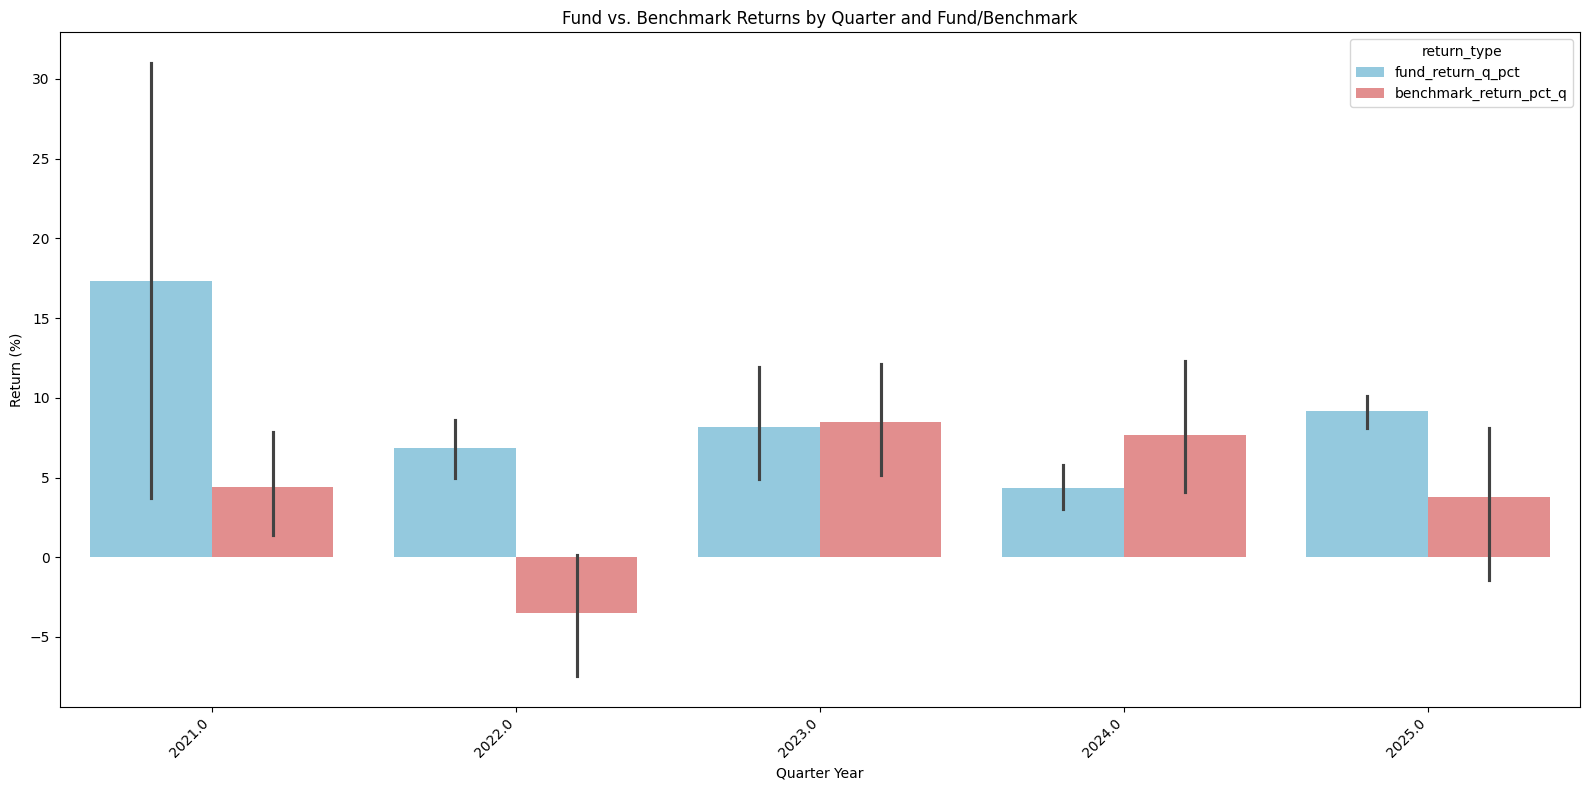

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
sns.barplot(
    data=df_melted,
    x='quarter_year',
    y='return_pct',
    hue='return_type',
    palette={'fund_return_q_pct': 'skyblue', 'benchmark_return_pct_q': 'lightcoral'}
)
plt.xlabel("Quarter Year")
plt.ylabel("Return (%)")
plt.title("Fund vs. Benchmark Returns by Quarter and Fund/Benchmark")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
Visualize the fund and benchmark returns side-by-side for each data point using a bar plot and differentiate between fund and benchmark returns using color. Add appropriate labels and title to the plot.

## Customize the plot

### Subtask:
Customize the plot created in the previous step to enhance its readability and informativeness.

## Prepare the data

### Subtask:
Select the necessary columns from the `df` DataFrame, specifically focusing on `fund_name`, `quarter_label`, `quarter_year`, `fund_return_q_pct`, `benchmark_name`, and `benchmark_return_pct_q`.

In [29]:
df_returns = df[[
    'fund_name',
    'quarter_label',
    'quarter_year',
    'fund_return_q_pct',
    'benchmark_name',
    'benchmark_return_pct_q'
]].copy()
display(df_returns.head())

,fund_name,quarter_label,quarter_year,fund_return_q_pct,benchmark_name,benchmark_return_pct_q
0,Cedar Creek Partners LLC,Q3,2022.0,8.8,S&P 500,7.6
1,Cedar Creek Partners LLC,Q3,2022.0,8.8,Russell 2000,6.2
2,Cedar Creek Partners LLC,Q4,2023.0,20.3,S&P 500,26.2
3,Cedar Creek Partners LLC,Q4,2023.0,20.3,Russell 2000,16.9
4,Cedar Creek Partners LLC,Q1,2024.0,NaN,S&P 500,24.9


**Reasoning**:
Create a new DataFrame with the specified columns for visualization.

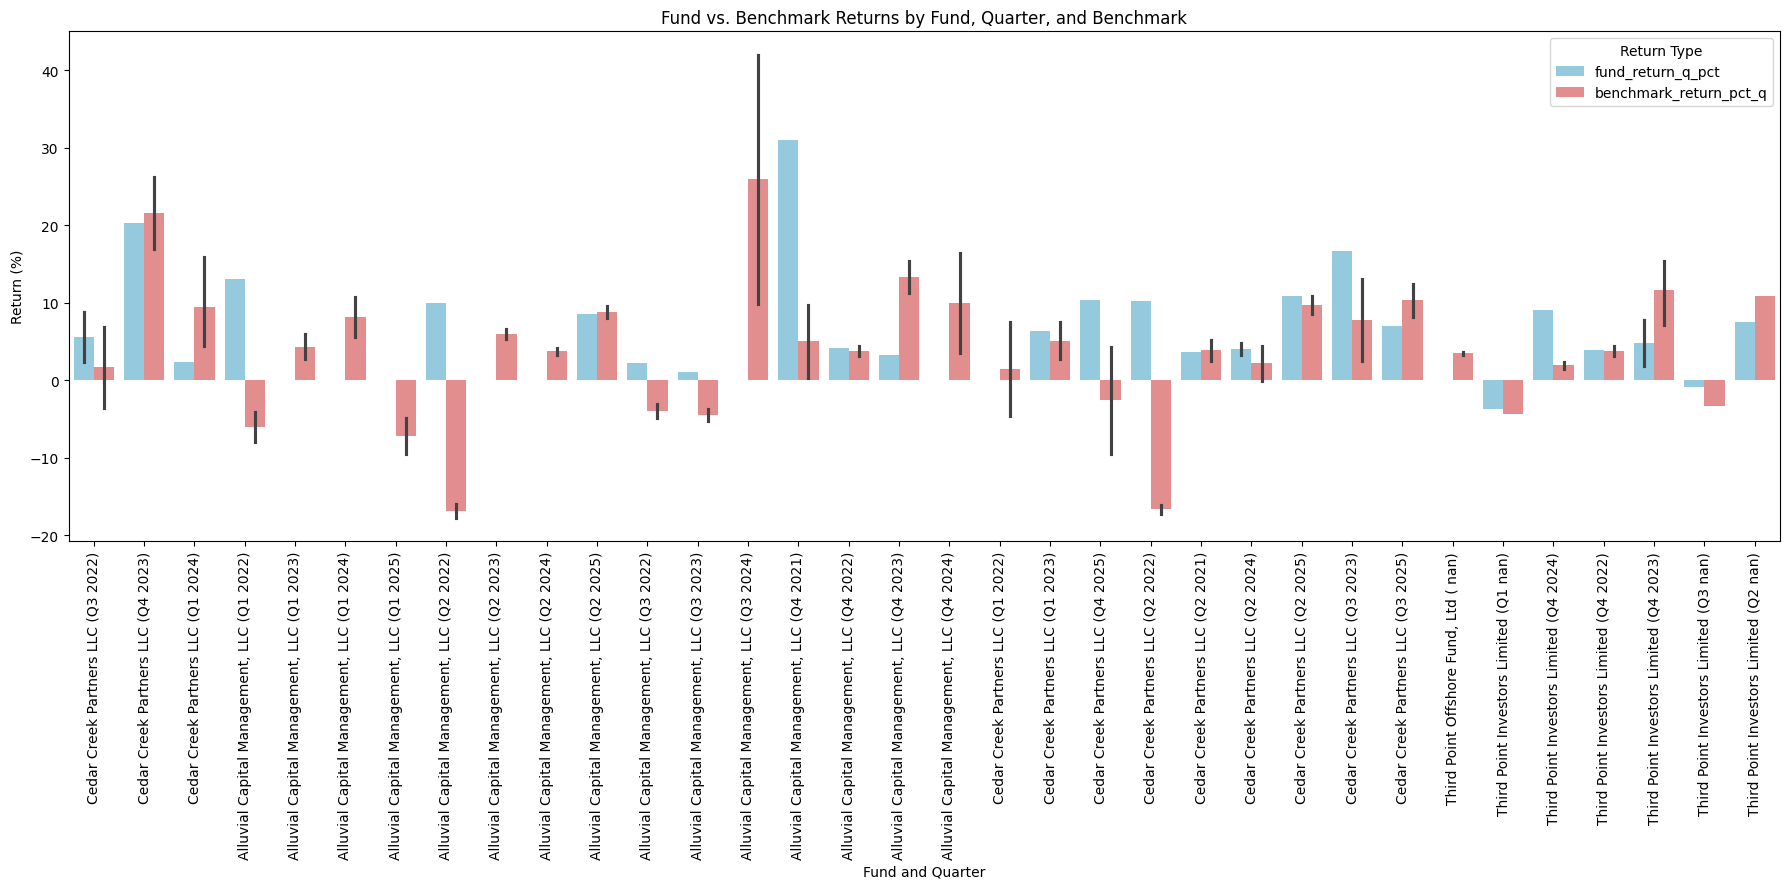

In [32]:
plt.figure(figsize=(18, 9))

# Combine fund_name, quarter_year, and quarter_label for a better x-axis representation
# We'll create a new column in df_melted for this
df_melted['fund_quarter'] = df_melted['fund_name'] + ' (' + df_melted['quarter_label'] + ' ' + df_melted['quarter_year'].astype(str).str.replace('.0', '', regex=False) + ')'

sns.barplot(
    data=df_melted,
    x='fund_quarter', # Use the combined column for x-axis
    y='return_pct',
    hue='return_type',
    palette={'fund_return_q_pct': 'skyblue', 'benchmark_return_pct_q': 'lightcoral'}
)

plt.xlabel("Fund and Quarter") # Update x-axis label
plt.ylabel("Return (%)")
plt.title("Fund vs. Benchmark Returns by Fund, Quarter, and Benchmark") # Update title
plt.xticks(rotation=90, ha='center') # Rotate labels more steeply and center them
plt.legend(title='Return Type') # Add a legend title
plt.tight_layout()
plt.show()

**Reasoning**:
Refine the plot by improving axis labels, title, and legend for better clarity. Adjust x-axis to group by fund and quarter for a more direct comparison of fund vs. benchmark within each period.

# Task
Visualize fund return vs benchmark return from the dataframe `df`.

## Prepare the data

### Subtask:
Select the necessary columns from the `df` DataFrame, specifically focusing on `fund_name`, `quarter_label`, `quarter_year`, `fund_return_q_pct`, `benchmark_name`, and `benchmark_return_pct_q`.


**Reasoning**:
Create a new DataFrame with the specified columns for visualization.



In [26]:
df_returns = df[[
    'fund_name',
    'quarter_label',
    'quarter_year',
    'fund_return_q_pct',
    'benchmark_name',
    'benchmark_return_pct_q'
]].copy()
display(df_returns.head())

,fund_name,quarter_label,quarter_year,fund_return_q_pct,benchmark_name,benchmark_return_pct_q
0,Cedar Creek Partners LLC,Q3,2022.0,8.8,S&P 500,7.6
1,Cedar Creek Partners LLC,Q3,2022.0,8.8,Russell 2000,6.2
2,Cedar Creek Partners LLC,Q4,2023.0,20.3,S&P 500,26.2
3,Cedar Creek Partners LLC,Q4,2023.0,20.3,Russell 2000,16.9
4,Cedar Creek Partners LLC,Q1,2024.0,NaN,S&P 500,24.9


## Melt the dataframe

### Subtask:
Reshape the DataFrame `df_returns` so that fund returns and benchmark returns are in the same column, with another column indicating whether the return is for the fund or the benchmark.


**Reasoning**:
Reshape the DataFrame `df_returns` by melting the return columns into a single column for visualization.



In [27]:
df_melted = pd.melt(
    df_returns,
    id_vars=['fund_name', 'quarter_label', 'quarter_year', 'benchmark_name'],
    value_vars=['fund_return_q_pct', 'benchmark_return_pct_q'],
    var_name='return_type',
    value_name='return_pct'
)
display(df_melted.head())

,fund_name,quarter_label,quarter_year,benchmark_name,return_type,return_pct
0,Cedar Creek Partners LLC,Q3,2022.0,S&P 500,fund_return_q_pct,8.8
1,Cedar Creek Partners LLC,Q3,2022.0,Russell 2000,fund_return_q_pct,8.8
2,Cedar Creek Partners LLC,Q4,2023.0,S&P 500,fund_return_q_pct,20.3
3,Cedar Creek Partners LLC,Q4,2023.0,Russell 2000,fund_return_q_pct,20.3
4,Cedar Creek Partners LLC,Q1,2024.0,S&P 500,fund_return_q_pct,NaN


## Visualize the data

### Subtask:
Create a plot showing the fund return and the benchmark return side-by-side for each data point using the melted dataframe `df_melted`.


**Reasoning**:
Visualize the fund and benchmark returns side-by-side for each data point using a bar plot and differentiate between fund and benchmark returns using color. Add appropriate labels and title to the plot.



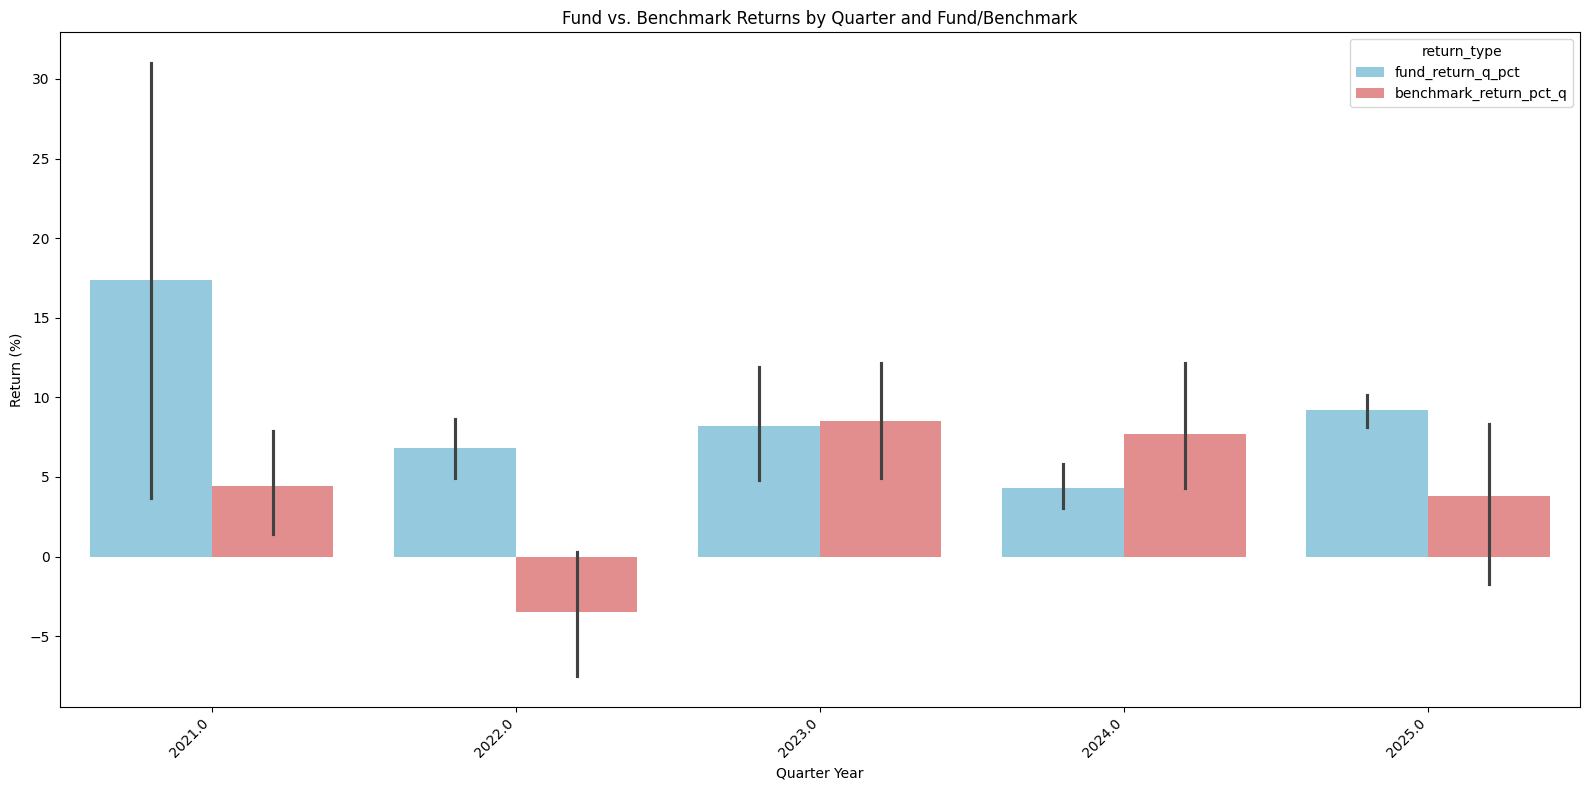

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
sns.barplot(
    data=df_melted,
    x='quarter_year',
    y='return_pct',
    hue='return_type',
    palette={'fund_return_q_pct': 'skyblue', 'benchmark_return_pct_q': 'lightcoral'}
)
plt.xlabel("Quarter Year")
plt.ylabel("Return (%)")
plt.title("Fund vs. Benchmark Returns by Quarter and Fund/Benchmark")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The analysis successfully prepared, reshaped, and visualized the fund return versus benchmark return data.
*   A melted DataFrame (`df_melted`) was created to facilitate the side-by-side comparison of fund and benchmark returns.
*   A bar plot was generated showing `return_pct` on the y-axis and `quarter_year` on the x-axis, with `return_type` differentiating between fund and benchmark returns using distinct colors.

### Insights or Next Steps

*   Analyze periods where the fund significantly outperformed or underperformed the benchmark to understand potential drivers.


# Task
Visualize the average alpha over time from the data in the dataframe `df`.

## Prepare data for time series

### Subtask:
Group the DataFrame `df` by `quarter_year` and `quarter_label` and calculate the average `alpha_pct_q` for each quarter.


**Reasoning**:
Group the DataFrame by quarter and calculate the average alpha, then display the result.



In [35]:
average_alpha_over_time = df.groupby(['quarter_year', 'quarter_label'])['alpha_pct_q'].mean().reset_index()
display(average_alpha_over_time.head())

,quarter_year,quarter_label,alpha_pct_q
0,2021.0,Q2,-0.150000
1,2021.0,Q4,26.001112
2,2022.0,Q1,19.016501
3,2022.0,Q2,26.817599
4,2022.0,Q3,4.665040


## Order the data

### Subtask:
Ensure the data is sorted chronologically by year and quarter so the time series plot makes sense.


**Reasoning**:
Sort the DataFrame by year and quarter and reset the index to prepare for plotting.



In [36]:
average_alpha_over_time = average_alpha_over_time.sort_values(by=['quarter_year', 'quarter_label']).reset_index(drop=True)
display(average_alpha_over_time.head())

,quarter_year,quarter_label,alpha_pct_q
0,2021.0,Q2,-0.150000
1,2021.0,Q4,26.001112
2,2022.0,Q1,19.016501
3,2022.0,Q2,26.817599
4,2022.0,Q3,4.665040


## Visualize average alpha

### Subtask:
Create a line plot showing the average `alpha_pct_q` on the y-axis and time (represented by year and quarter) on the x-axis.


**Reasoning**:
Create a line plot showing the average alpha over time using the sorted data.



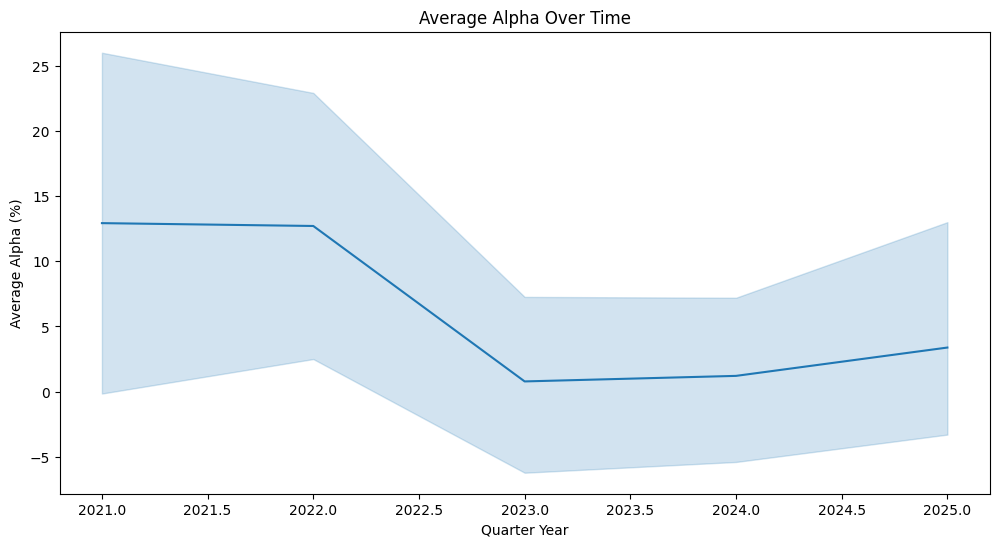

In [37]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_alpha_over_time, x='quarter_year', y='alpha_pct_q')
plt.xlabel("Quarter Year")
plt.ylabel("Average Alpha (%)")
plt.title("Average Alpha Over Time")
plt.show()

## Customize the plot

### Subtask:
Customize the plot created in the previous step to enhance its readability and informativeness.


**Reasoning**:
Create a new column combining year and quarter for the x-axis, then create the line plot with enhanced labels and title, rotate x-axis labels, and ensure a tight layout.



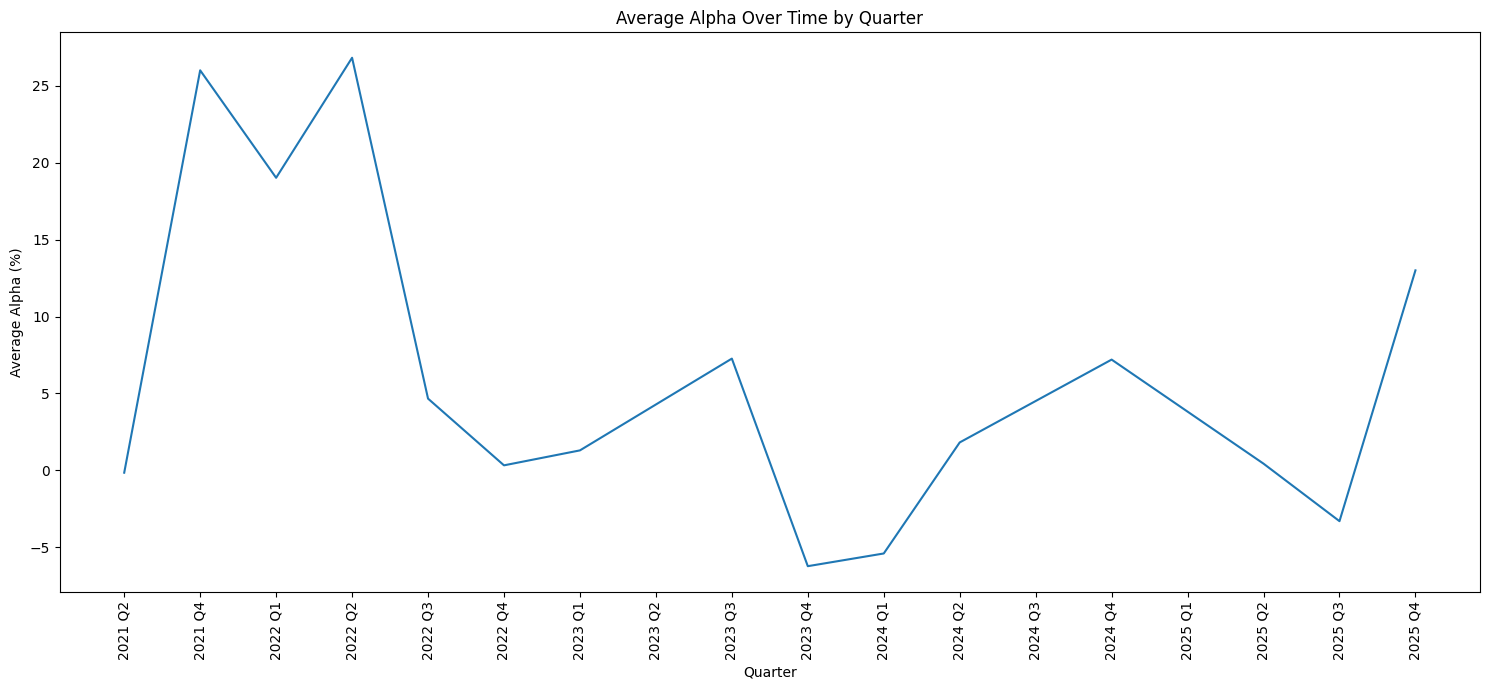

In [38]:
average_alpha_over_time['quarter'] = average_alpha_over_time['quarter_year'].astype(int).astype(str) + ' ' + average_alpha_over_time['quarter_label']

plt.figure(figsize=(15, 7))
sns.lineplot(data=average_alpha_over_time, x='quarter', y='alpha_pct_q')
plt.xlabel("Quarter")
plt.ylabel("Average Alpha (%)")
plt.title("Average Alpha Over Time by Quarter")
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

## Display the plot

### Subtask:
Display the generated visualization of average alpha over time.


**Reasoning**:
Display the previously generated plot of average alpha over time.



In [39]:
plt.show()

## Summary:

### Data Analysis Key Findings

* The average alpha percentage was calculated for each quarter by grouping the data by `quarter_year` and `quarter_label`.
* The data was sorted chronologically by year and quarter to ensure a correct time series representation.
* A line plot was generated showing the trend of average alpha over time.
* A new 'quarter' column was created by combining the year and quarter label for better x-axis labeling on the final plot.
* The final plot visually represents the average alpha over time by quarter with rotated x-axis labels for improved readability.

### Insights or Next Steps

* Analyze the trend in average alpha over time to identify periods of significant increase or decrease.
* Investigate factors that might contribute to the observed fluctuations in average alpha.


# Task
Analyze and visualize the performance of different hedge fund managers over time based on the data extracted from PDF reports in the "/content/HedgeFundLetters" folder. The analysis should include visualizing fund return vs benchmark return, analyzing the relationship between fund and benchmark returns, calculating and summarizing the average alpha by manager, visualizing average alpha over time, and comparing individual manager performance over time.

## Prepare data for comparison

### Subtask:
Select relevant columns including manager name, quarter, year, fund return, and alpha.


**Reasoning**:
Create a new DataFrame with the specified columns and display the head.



In [40]:
df_performance = df[[
    'manager_name',
    'quarter_label',
    'quarter_year',
    'fund_return_q_pct',
    'alpha_pct_q'
]].copy()
display(df_performance.head())

,manager_name,quarter_label,quarter_year,fund_return_q_pct,alpha_pct_q
0,Tim Eriksen,Q3,2022.0,8.8,1.2
1,Tim Eriksen,Q3,2022.0,8.8,2.6
2,Tim Eriksen,Q4,2023.0,20.3,-5.9
3,Tim Eriksen,Q4,2023.0,20.3,3.4
4,Tim Eriksen,Q1,2024.0,NaN,NaN


## Handle missing data

### Subtask:
Address any missing values in the performance metrics that might affect the time series visualization.


**Reasoning**:
Inspect the `df_performance` DataFrame for missing values in the `fund_return_q_pct` and `alpha_pct_q` columns to understand the extent of the missing data.



In [41]:
print("Missing values in df_performance:")
print(df_performance.isnull().sum())

Missing values in df_performance:
manager_name          0
quarter_label         0
quarter_year         10
fund_return_q_pct    22
alpha_pct_q          25
dtype: int64


**Reasoning**:
Since `quarter_year`, `fund_return_q_pct`, and `alpha_pct_q` have missing values which are crucial for time series analysis and performance visualization, the most appropriate strategy is to drop rows where these key metrics are missing to avoid distorting the trends.



In [42]:
df_performance_cleaned = df_performance.dropna(subset=['quarter_year', 'fund_return_q_pct', 'alpha_pct_q']).copy()
print("\nMissing values in df_performance_cleaned after dropping rows:")
print(df_performance_cleaned.isnull().sum())
display(df_performance_cleaned.head())


Missing values in df_performance_cleaned after dropping rows:
manager_name         0
quarter_label        0
quarter_year         0
fund_return_q_pct    0
alpha_pct_q          0
dtype: int64


,manager_name,quarter_label,quarter_year,fund_return_q_pct,alpha_pct_q
0,Tim Eriksen,Q3,2022.0,8.8,1.200000
1,Tim Eriksen,Q3,2022.0,8.8,2.600000
2,Tim Eriksen,Q4,2023.0,20.3,-5.900000
3,Tim Eriksen,Q4,2023.0,20.3,3.400000
6,Dave Waters,Q1,2022.0,13.0,17.046856


## Visualize individual manager performance

### Subtask:
Create a line plot showing performance metric (e.g., `alpha_pct_q` or `fund_return_q_pct`) on the y-axis and time on the x-axis, with different lines representing each manager.


**Reasoning**:
Create a new column combining year and quarter, then create the line plot showing alpha over time for each manager.



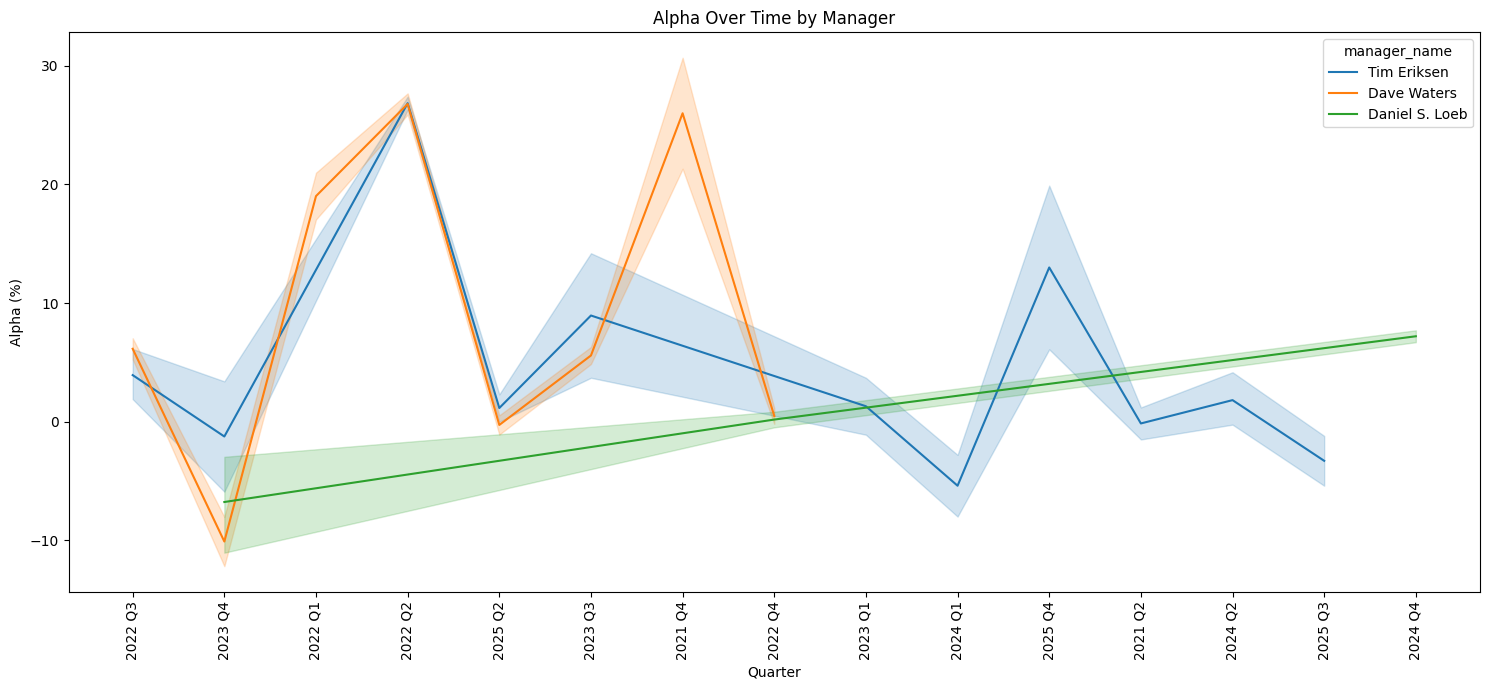

In [43]:
df_performance_cleaned['quarter'] = df_performance_cleaned['quarter_year'].astype(int).astype(str) + ' ' + df_performance_cleaned['quarter_label']

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_performance_cleaned, x='quarter', y='alpha_pct_q', hue='manager_name')
plt.xlabel("Quarter")
plt.ylabel("Alpha (%)")
plt.title("Alpha Over Time by Manager")
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

## Customize the plot

### Subtask:
Customize the plot created in the previous step to enhance its readability and informativeness.


## Display the plot

### Subtask:
Display the generated visualization of individual manager performance over time.


**Reasoning**:
Display the previously generated plot of individual manager performance over time.



In [44]:
plt.show()

## Summary:

### Data Analysis Key Findings

*   The analysis focused on manager name, quarter, year, fund return, and alpha, which were successfully extracted and combined into a single DataFrame `df_performance`.
*   Missing values in the key performance metrics (`quarter_year`, `fund_return_q_pct`, and `alpha_pct_q`) were identified and handled by dropping corresponding rows, resulting in a cleaned DataFrame `df_performance_cleaned`.
*   A time-based index 'quarter' was created by combining 'quarter\_year' and 'quarter\_label'.
*   A line plot visualizing the alpha over time for each hedge fund manager was successfully generated and displayed.

### Insights or Next Steps

*   The visualization of alpha over time by manager allows for a direct comparison of individual manager performance trends. Further analysis could involve calculating and visualizing other performance metrics like Sharpe ratio or Sortino ratio over time for each manager.
*   Investigating periods where certain managers significantly outperformed or underperformed the others could reveal potential factors influencing their performance.
